In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
listed = pd.read_csv("listed_final.csv", low_memory=False)
sold = pd.read_csv("sold_final.csv", low_memory=False)

In [5]:
date_cols = [col for col in sold.columns if "date" in col.lower()]
for col in date_cols:
    listed[col] = pd.to_datetime(listed[col], errors="coerce")
    sold[col] = pd.to_datetime(sold[col], errors="coerce")

In [42]:
listed[date_cols].head()

,CloseDate,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate
0,NaT,2024-05-07,2024-05-07,2024-01-01
1,NaT,2024-01-24,NaT,2024-01-24
2,NaT,2024-01-12,NaT,2024-01-12
3,NaT,2024-01-20,NaT,2024-01-20
4,NaT,2024-01-12,NaT,2024-01-12


In [43]:
listed[listed["ListingContractDate"] > listed["CloseDate"]][date_cols].head()

,CloseDate,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate
1406,2024-01-30,2024-01-30,2024-01-15,2024-01-31
4140,2024-01-25,2024-01-25,2024-01-10,2024-01-26
16405,2024-01-01,2024-01-01,2023-12-04,2024-01-02
41867,2024-03-20,2024-03-20,2024-03-03,2024-03-21
73352,2024-03-29,2024-03-29,2024-03-27,2024-04-08


In [56]:
pd.merge(listed, sold, on="ListingKey").filter(like="Date").query("CloseDate_y == ListingContractDate_y").shape

(3629, 8)

In [49]:
main_fields = ["ListingKey", "ListingContractDate", "ListPrice", "ClosePrice",
               "PurchaseContractDate", "CloseDate", "LivingArea", "BedroomsTotal",
               "BathroomsTotalInteger", "Latitude", "Longitude", "UnparsedAddress"]

In [57]:
sold.query("CloseDate < PurchaseContractDate")[main_fields]

,ListingKey,ListingContractDate,ListPrice,ClosePrice,PurchaseContractDate,CloseDate,LivingArea,BedroomsTotal,BathroomsTotalInteger,Latitude,Longitude,UnparsedAddress
3,1079166779,2024-01-30,858000.0,858000.0,2024-08-05,2024-01-30,1995.0,0.0,3.0,NaN,NaN,2199 N Berne Drive
7,1061988701,2024-01-31,2340000.0,2340000.0,2024-03-04,2024-01-31,2442.0,4.0,3.0,NaN,NaN,3114 Rasmus Circle
11,1060105211,2024-01-31,2150000.0,2150000.0,2024-02-05,2024-01-31,2200.0,3.0,2.0,NaN,NaN,1250 Roble Road
12,1060066702,2024-01-29,2000000.0,2000000.0,2024-02-04,2024-01-29,1690.0,3.0,2.0,NaN,NaN,3969 Casanova Drive
20,1059861172,2024-01-29,1928800.0,1928800.0,2024-02-01,2024-01-29,3799.0,4.0,5.0,NaN,NaN,298 Drummond Drive
...,...,...,...,...,...,...,...,...,...,...,...,...
286244,1126583974,2025-08-08,2020000.0,2020000.0,2025-08-11,2025-08-08,1650.0,3.0,2.0,37.530273,-122.346241,1455 Ascension Drive
286269,1126190632,2025-08-08,1300000.0,1300000.0,2025-08-09,2025-08-08,1415.0,3.0,2.0,37.304324,-121.938769,1177 Whitehall Avenue
286286,1126050751,2025-08-07,1195000.0,1195000.0,2025-08-08,2025-08-07,1720.0,2.0,2.0,36.572868,-121.723452,24260 Pheasant Court
286402,1125643977,2025-08-04,6900000.0,6900000.0,2025-08-05,2025-08-04,4048.0,4.0,4.0,37.367832,-122.102589,840 Campbell Avenue


In [58]:
sold[sold["ClosePrice"] > sold["ListPrice"]]

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
9,PasadenaFoothills,PasadenaFoothills,Wood,True,NaN,NaN,False,999000.0,1061617422,kerry.kimble@theagencyre.com,...,90026,NaN,7128.0,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN
10,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,NaN,NaN,False,1050000.0,1060223286,aliciao@kw.com,...,90065,NaN,13029.0,NaN,CRMLS,CRMLS_CL,NaN,NaN,NaN,NaN
15,Southland,Southland,NaN,True,NaN,NaN,False,899800.0,1059954186,craigmartinhomes4u@gmail.com,...,91384,0.0,30078.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396999,Burbank,Burbank,Vinyl,True,NaN,NaN,False,599900.0,1084829227,NaN,...,90028,1047.8,12604.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
397006,CitrusValley,InlandValleys,NaN,False,NaN,NaN,False,499950.0,1077465967,NaN,...,91786,0.0,18800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
397010,NaN,Mlslistings,NaN,False,NaN,NaN,NaN,795111.0,1076156459,NaN,...,92346,NaN,14080.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
397011,Mrmls,Glendale,NaN,False,NaN,NaN,False,299000.0,1076094208,NaN,...,93551,0.0,8696.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [2]:
numeric_fields = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
                  "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket",
                  "YearBuilt"]

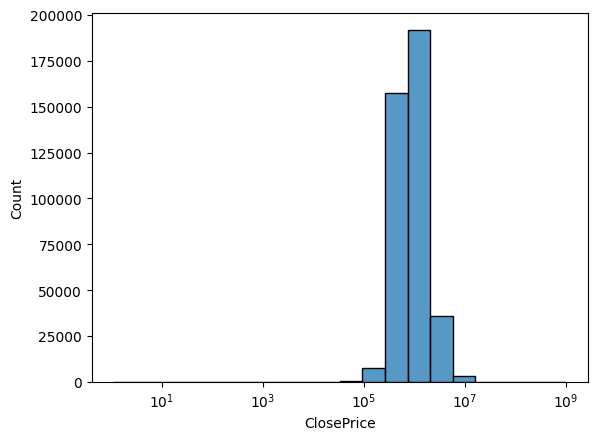

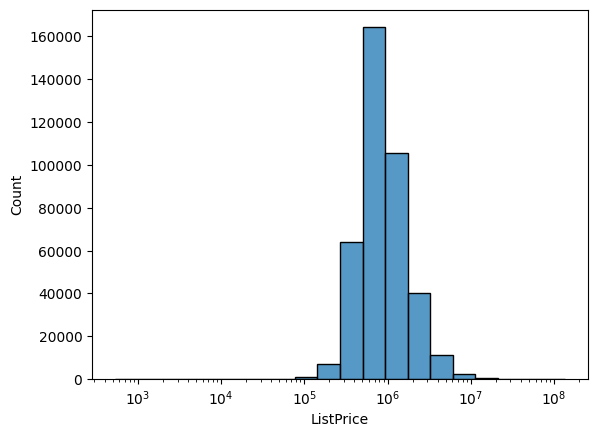

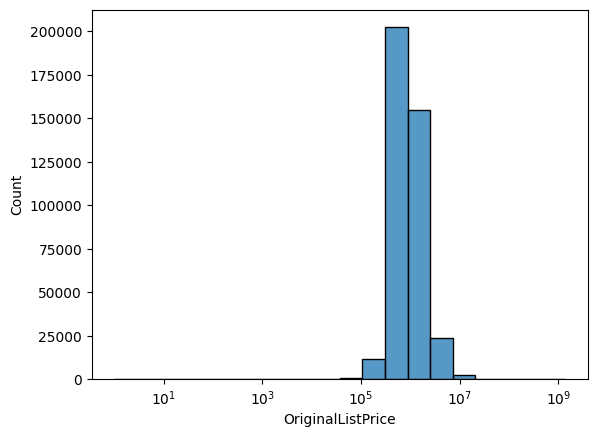

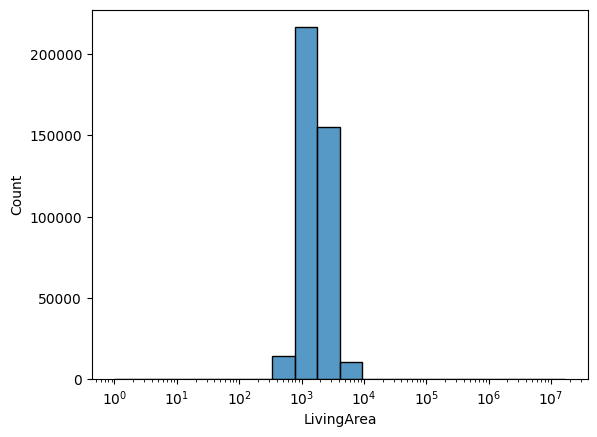

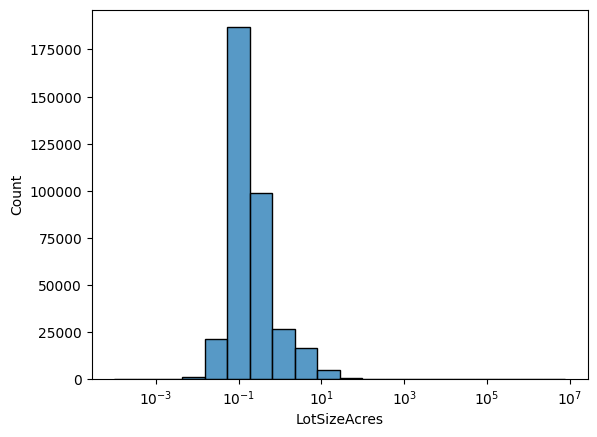

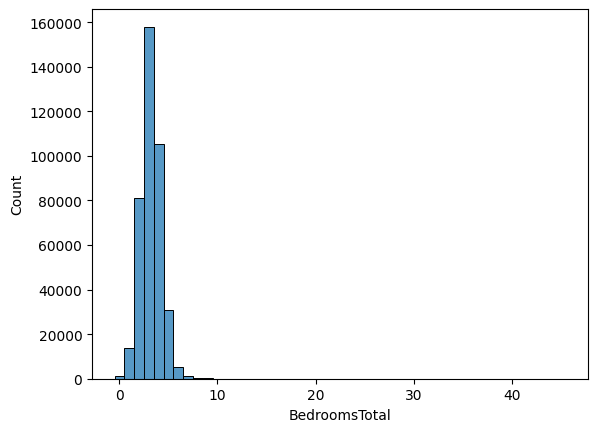

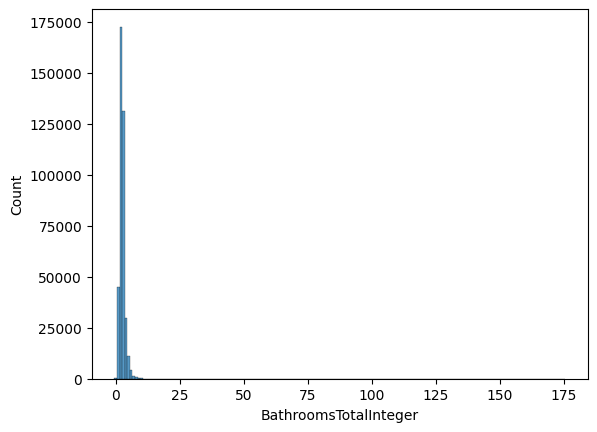

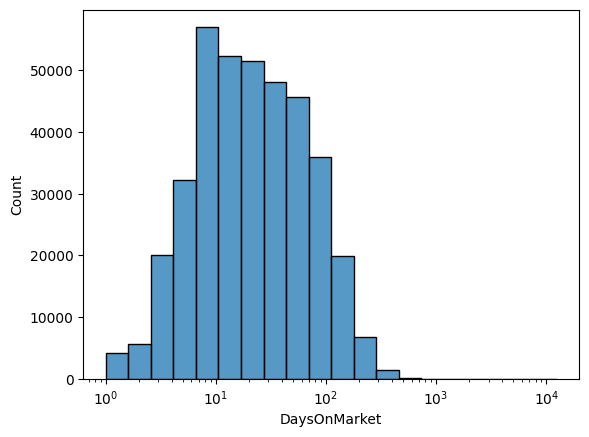

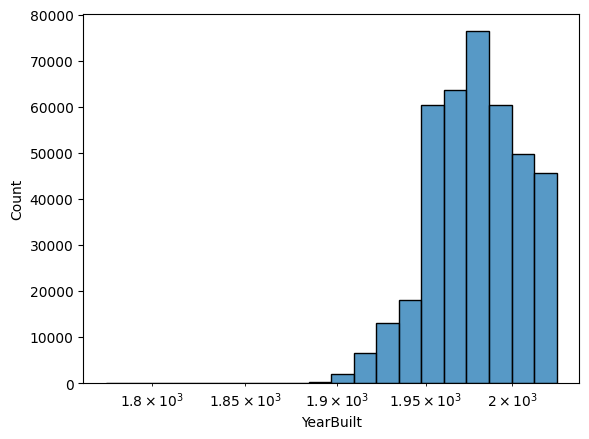

In [8]:
# plot numeric fields
for field in numeric_fields:
    plt.figure()
    if field not in ["BedroomsTotal", "BathroomsTotalInteger"]:
        sns.histplot(data=sold, x=field, bins=20, log_scale=True)
    else:
        sns.histplot(data=sold, x=field, discrete=True)
    plt.show()

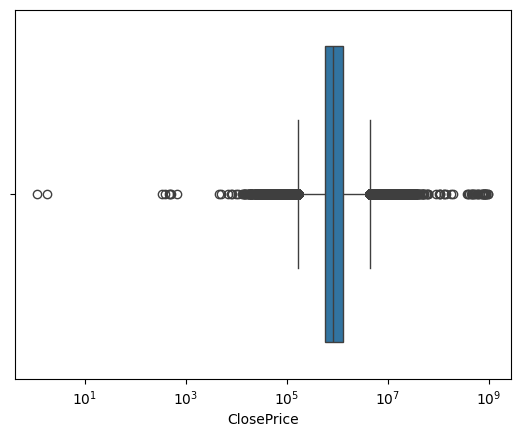

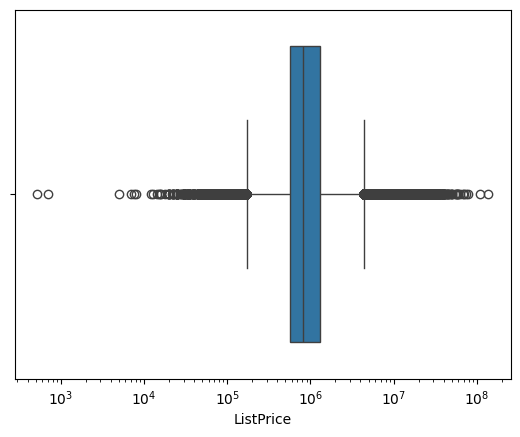

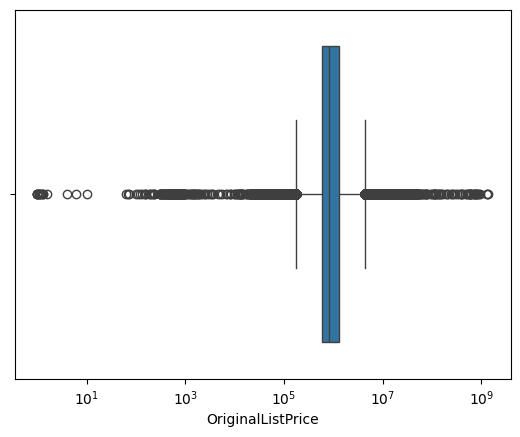

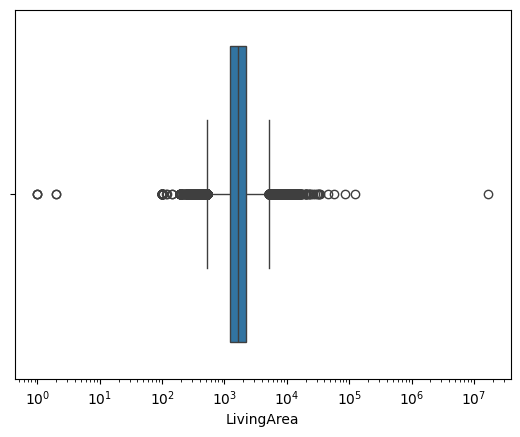

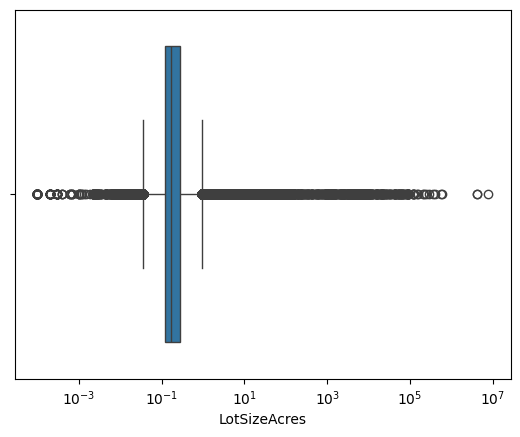

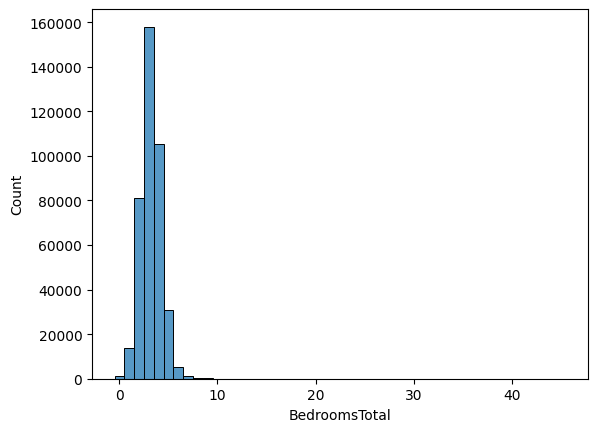

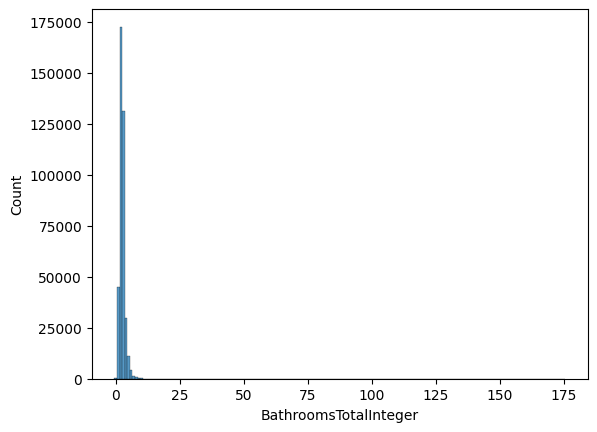

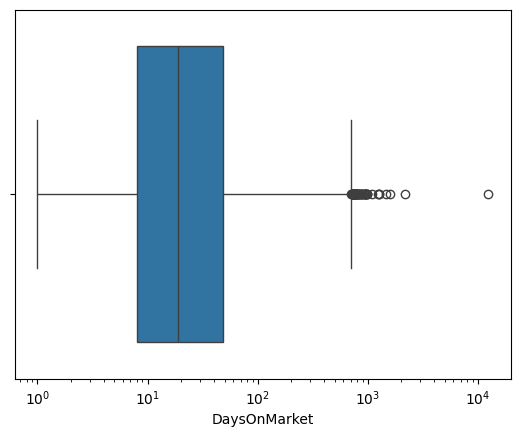

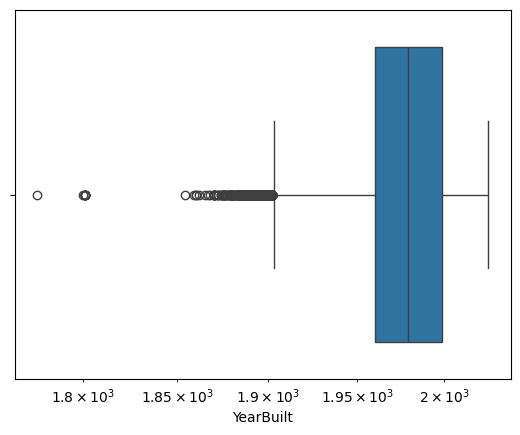

In [9]:
for field in numeric_fields:
    plt.figure()
    if field not in ["BedroomsTotal", "BathroomsTotalInteger"]:
        sns.boxplot(data=sold, x=field, log_scale=True)
    else:
        sns.histplot(data=sold, x=field, discrete=True)
    plt.show()

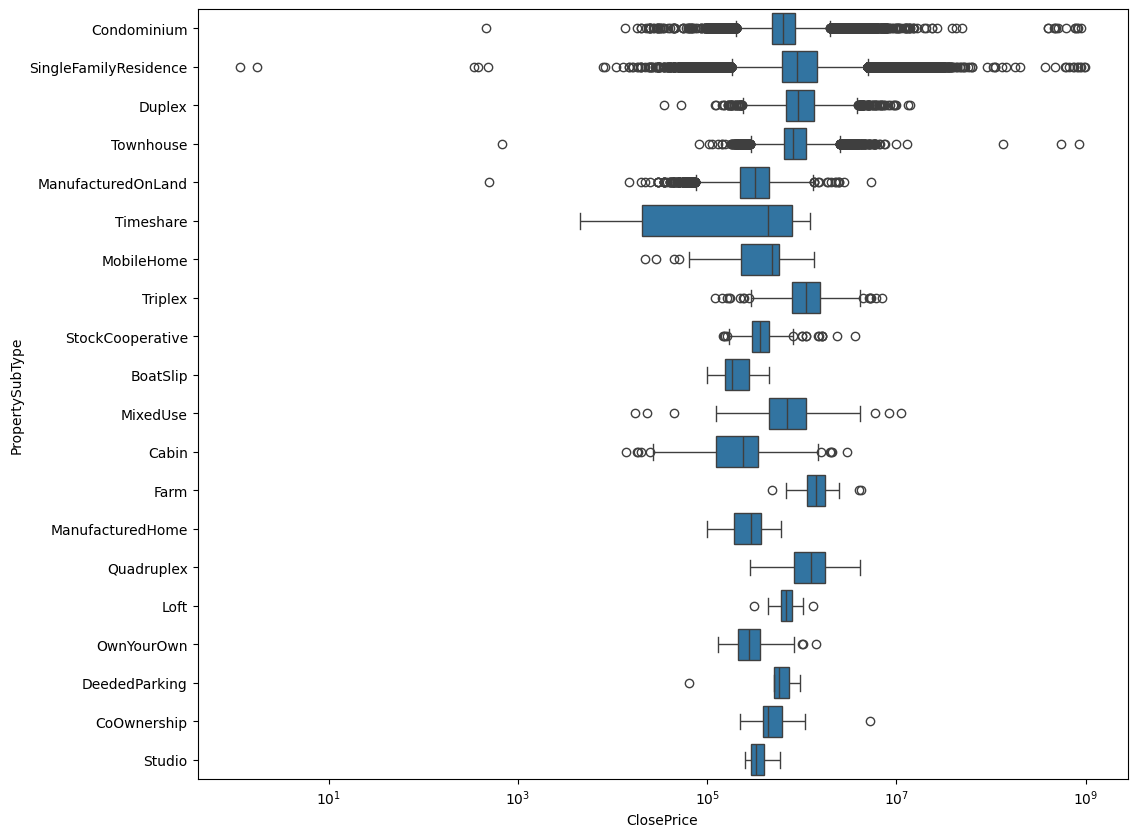

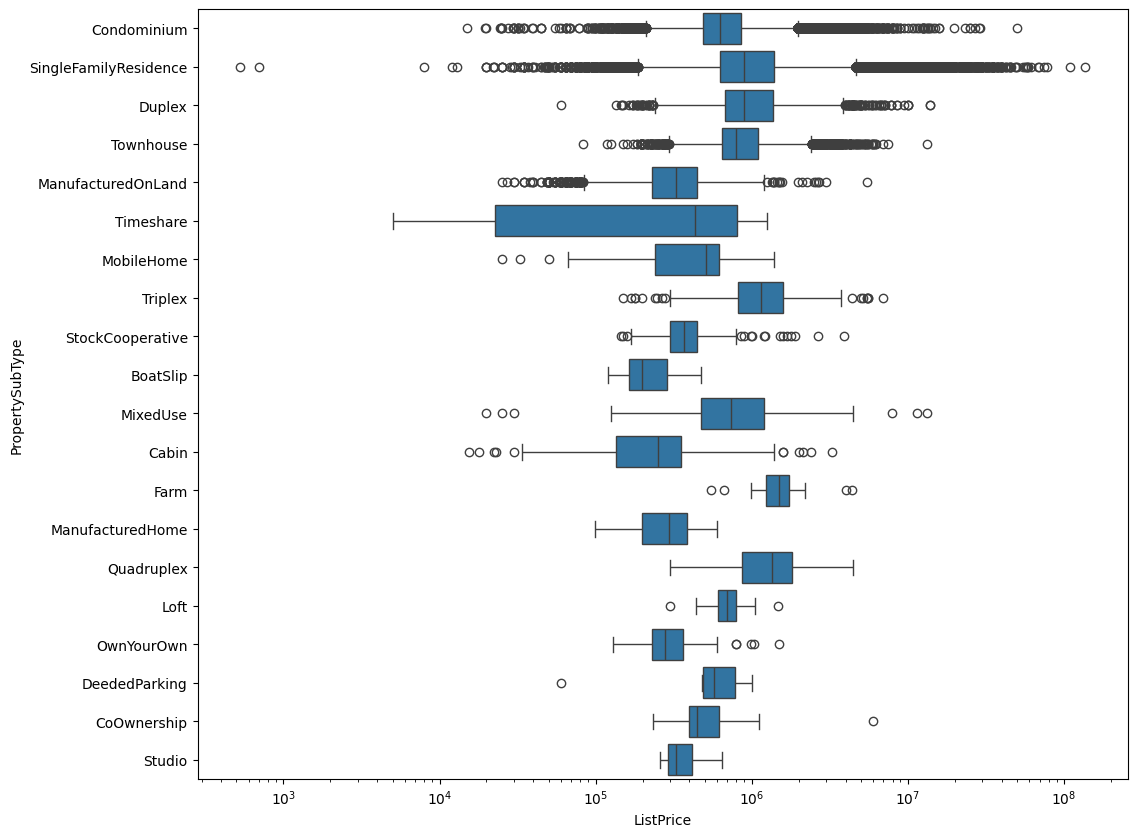

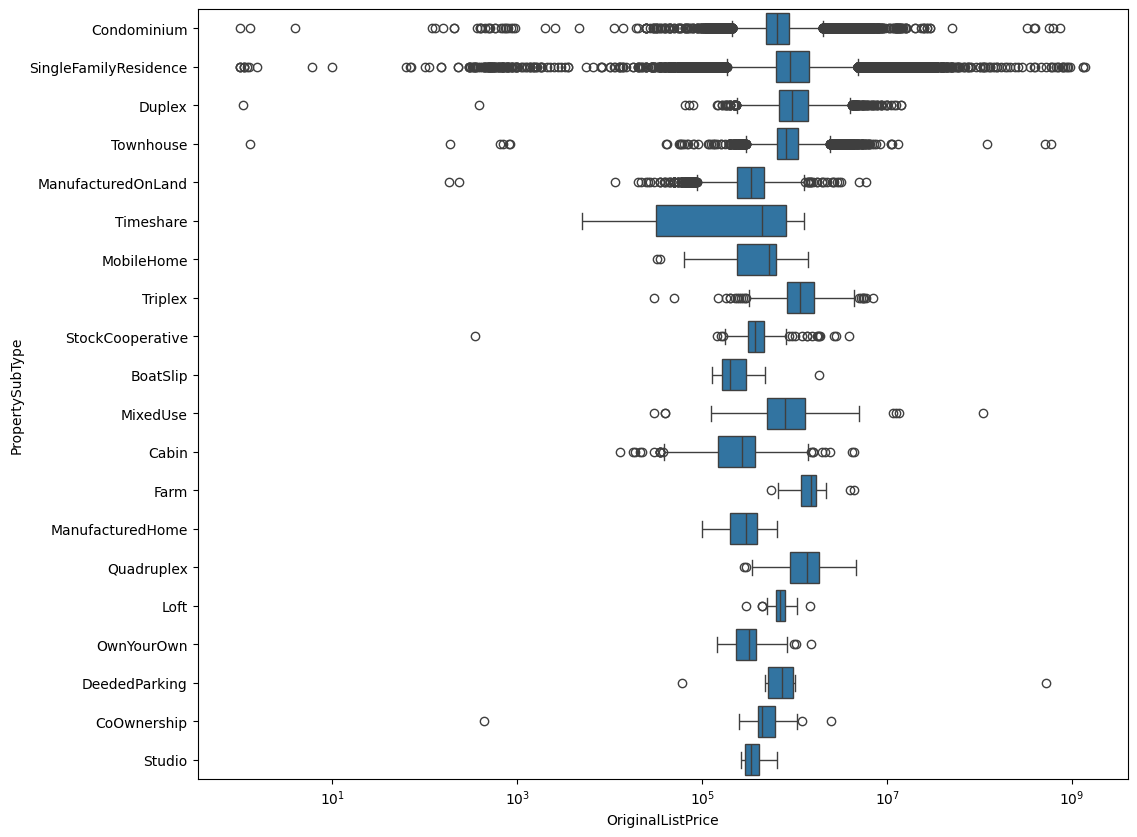

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


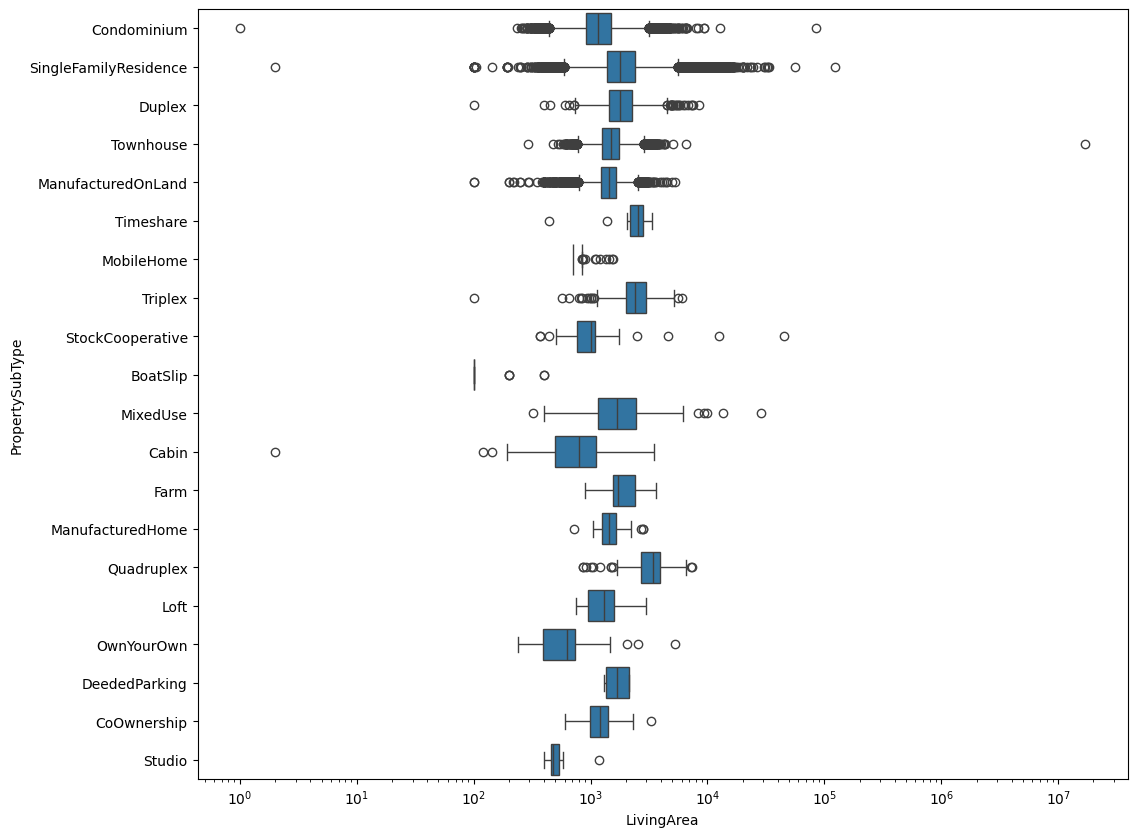

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


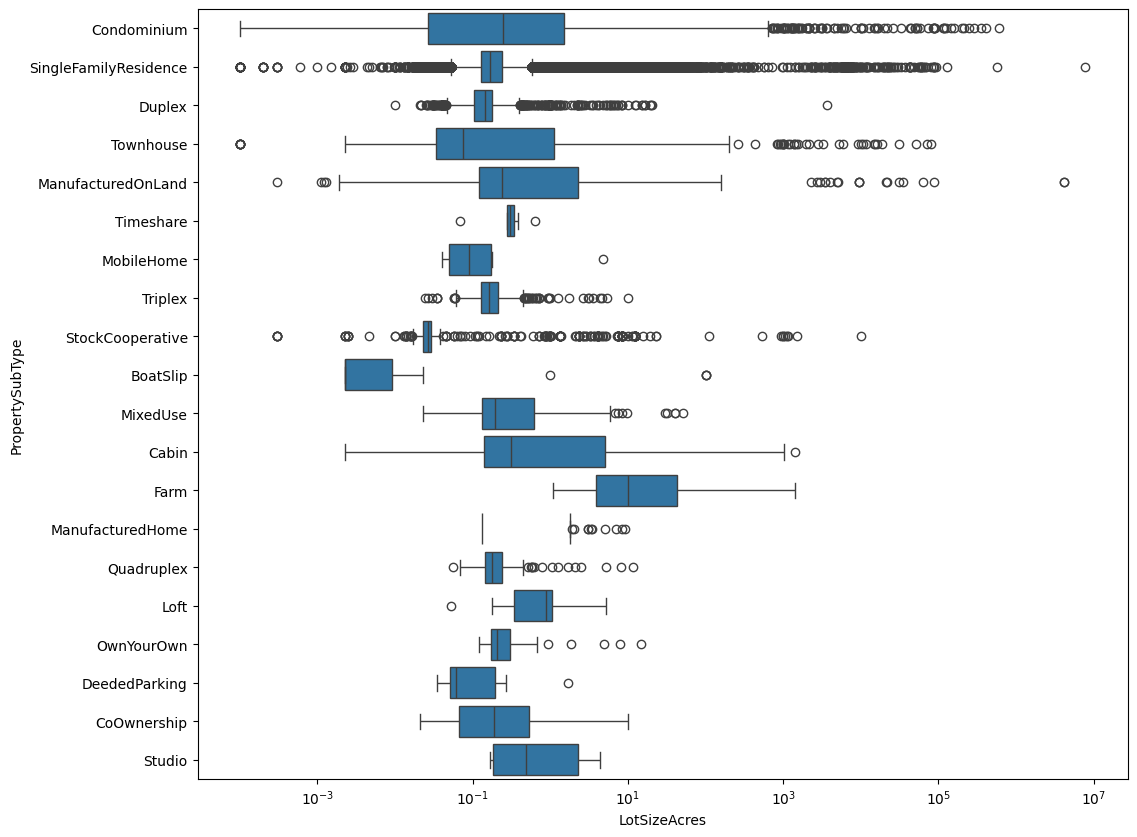

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


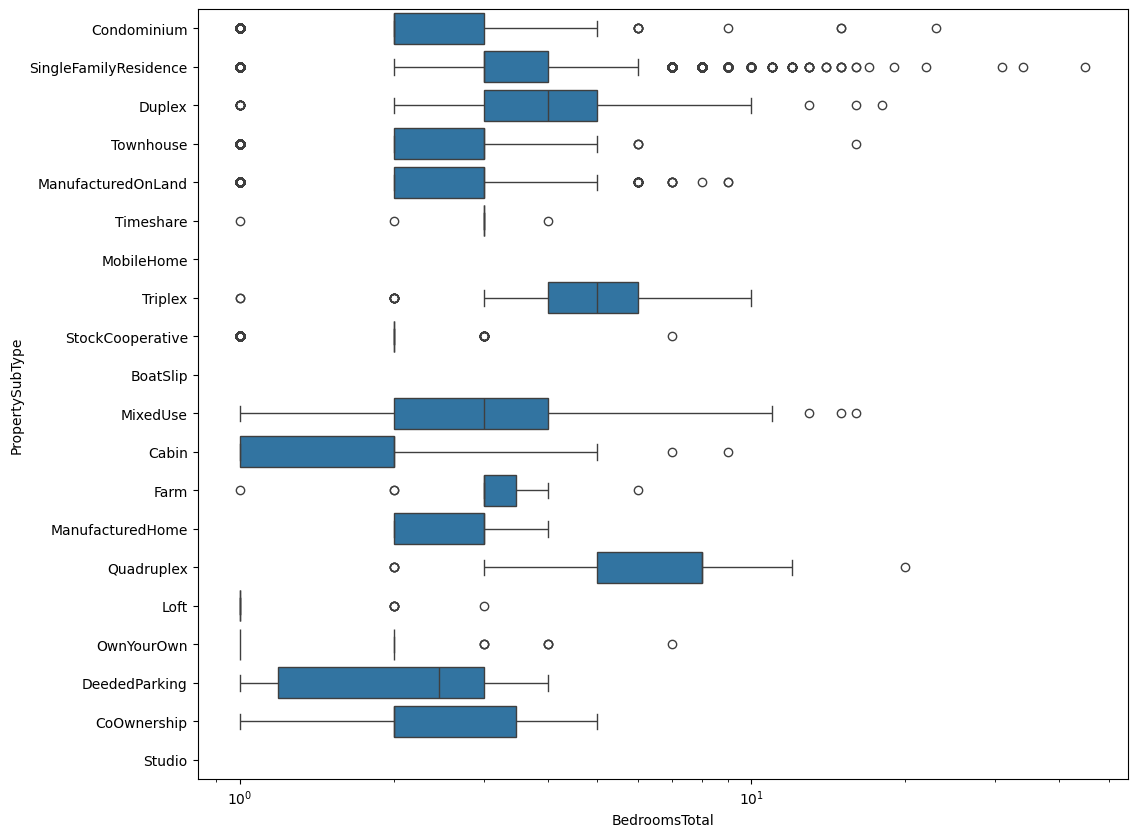

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


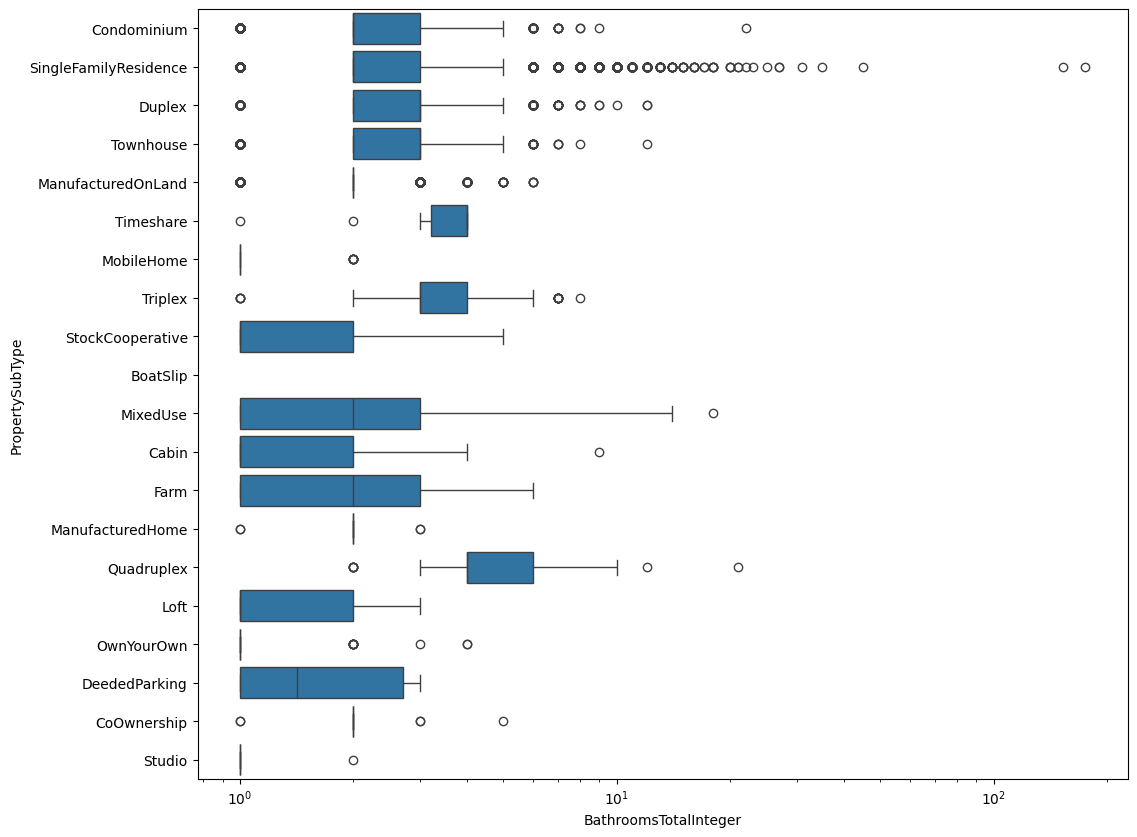

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4597: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = add(a, diff_b_a * t, out=... if out is None else out)


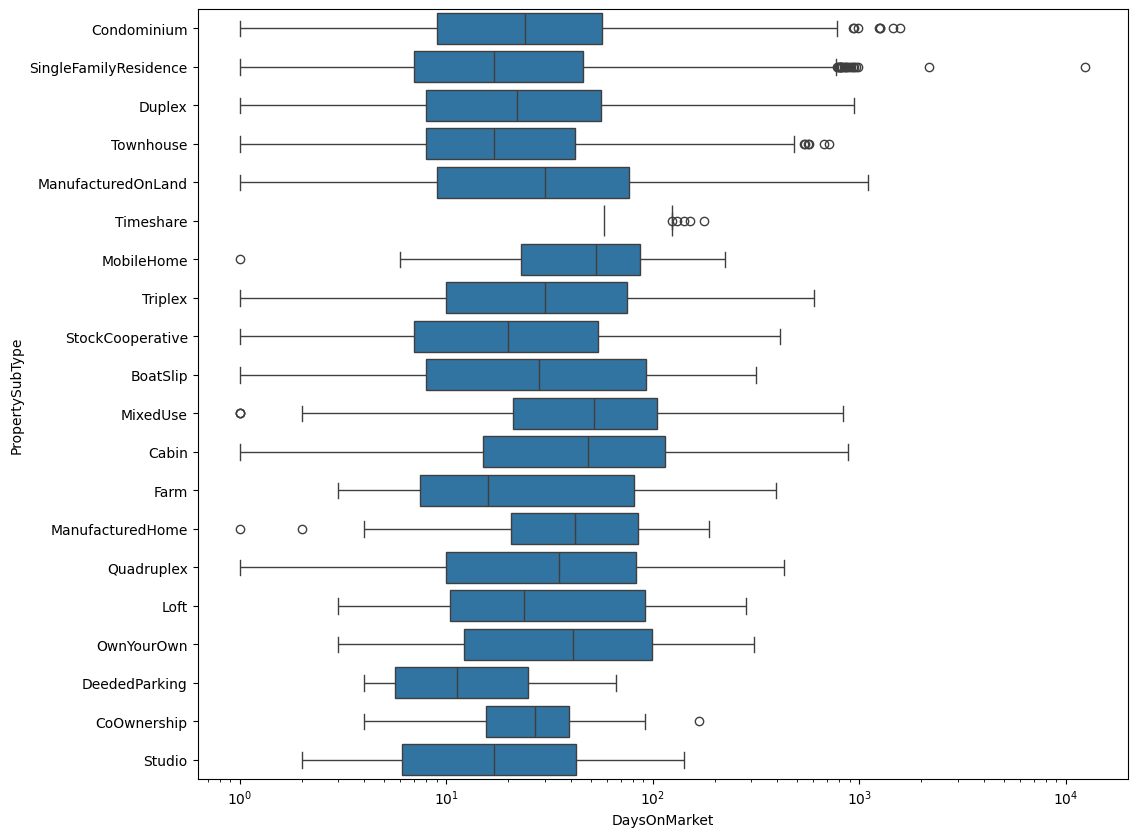

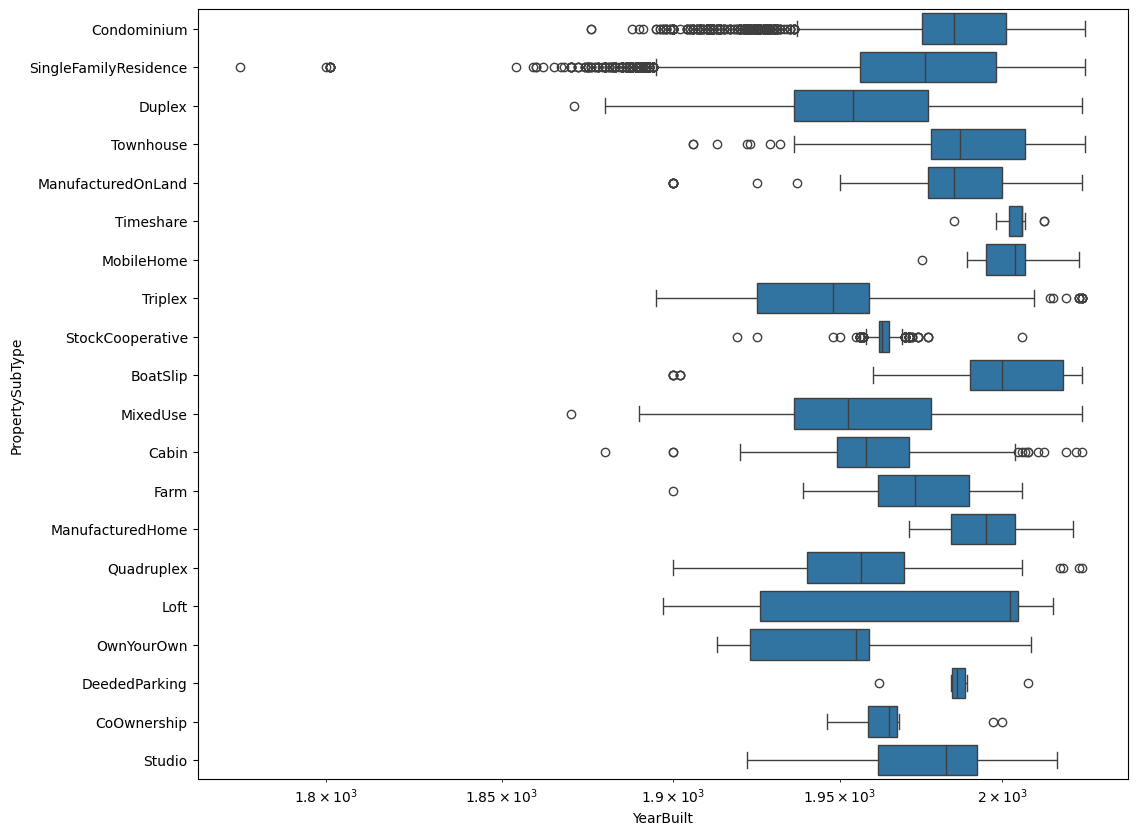

In [13]:
for field in numeric_fields:
    plt.figure(figsize=(12, 10))
    sns.boxplot(data=sold, x=field, y="PropertySubType", log_scale=True)
    plt.show()